## WLCF Example

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt


import camb
from camb import model
from wlcfpy import wlcf

# Change this path if your repo is somewhere else
WLCF_TESTS_DIR = '/home/sadi/LSST/test/wlcf-main/tests'
os.chdir(WLCF_TESTS_DIR)

os.makedirs('input', exist_ok=True)
os.makedirs('Output', exist_ok=True)
os.makedirs('Bell_outputs', exist_ok=True)

print('Running from:', os.getcwd())

Running from: /home/sadi/LSST/test/wlcf-main/tests


## Generate a linear power spectrum with CAMB

In [ ]:
def make_camb_linear_pk(
    output_file="./input/linear_pk_camb_T17_z05078.txt",
    z_pk=0.5078,
    h=0.7,
    Omb=0.046,
    Omc=0.233,
    Omnu=0.0,
    ns=0.97,
    sigma8=0.82,
    w0=-1.0,
    kmin=1e-4,
    kmax=50.0,
    npoints=1000,
):

    os.makedirs(os.path.dirname(output_file), exist_ok=True)

    H0 = 100.0 * h
    ombh2 = Omb * h**2
    omch2 = Omc * h**2

    pars = camb.CAMBparams()

    # For now we assume massless neutrinos, consistent with Omnu = 0.
    pars.set_cosmology(
        H0=H0,
        ombh2=ombh2,
        omch2=omch2,
    )

    pars.InitPower.set_params(
        ns=ns,
        As=2.1e-9
    )

    pars.set_dark_energy(w=w0)

    # Linear power spectrum at the same redshift used by wlcf/zbin
    pars.set_matter_power(
        redshifts=[z_pk],
        kmax=kmax
    )

    pars.NonLinear = model.NonLinear_none

    # First run to compute sigma8 for the trial As
    results = camb.get_results(pars)
    sigma8_current = results.get_sigma8()[0]

    # Rescale As so that CAMB matches the requested sigma8
    As_rescaled = 2.1e-9 * (sigma8 / sigma8_current) ** 2

    pars.InitPower.set_params(
        ns=ns,
        As=As_rescaled
    )

    results = camb.get_results(pars)

    kh, redshifts, pk = results.get_matter_power_spectrum(
        minkh=kmin,
        maxkh=kmax,
        npoints=npoints,
    )

    pk_z = pk[0]

    np.savetxt(
        output_file,
        np.column_stack([kh, pk_z]),
        fmt="%.10e"
    )

    print(f"Saved linear P(k) at z={z_pk} to:")
    print(output_file)
    print(f"sigma8 target  = {sigma8}")
    print(f"sigma8 CAMB    = {results.get_sigma8()[0]:.6f}")
    print(f"As rescaled    = {As_rescaled:.6e}")

    return output_file, kh, pk_z

In [3]:
pk_file, k, pk = make_camb_linear_pk()

Saved linear P(k) at z=0.5078 to:
./input/linear_pk_camb_T17_z05078.txt
sigma8 target  = 0.82
sigma8 CAMB    = 0.820000
As rescaled    = 3.728918e-09


## Run wlcf from Python


In [ ]:


w = wlcf()
w.set(
    numberThreads=8,
    verbose=2,
    verbose_log=1,

    # T17 / paper cosmology
    z=0.5078,
    h=0.7,
    sigma8=0.82,
    Omb=0.046,
    Omc=0.233,
    Omnu=0.0,
    ns=0.97,
    w=-1.0,

    # CAMB P(k) generated with the same cosmology and redshift
    fnamePS="./input/linear_pk_camb_T17_z05078.txt",

    # Weak lensing kernel / redshift bin
    Wg=0,
    fWgchi="./input/Wg_Takahashi_z05078.txt",

    rootDir="Output",
    path_Bells="Bell_outputs",
    prefix="halo_model_z05078_",


    tree_level=4,

    zbin=0.5078,
    mMax=5,
    chiQuadSteps=300,
    GLpoints=64,
    Nell=128,
    ellmax=10000,
    ellmin=0.001,
    writevectors=0,
    chatty=2,
    options=""
)

w.Run()


Reading input parameters...


20.116627962499997


startrun_memoryAllocation: Allocated 0 MByte for histograms storage.
StartRun_Common: OmegaM = : 0.279000
time evaluating background: 0.609219 s
iv.chiMaxInt = 1343.988284 Mpc/h
gv.chiBin    = 1349.890696 Mpc/h

Computing Bm(k1,k2) for symmetric array of 100 x 100 k1,k2 values  
Maxm=5, kmin=0.001000 ,kmax=1.000000, Nk=100, GLpoints=64 
z=0.507800, Dp=0.776513, rsigma=1.795962, neff=-1.897866 
Bnk time = 0.47442915 

time= 0.529176 

Bmell: Computing Bm(ell1,ell2) for symmetric 128 x 128 array of ell values
    ellmin = 0.001000, ellmax = 10000.000000  
    Number of moments = 6
    Quadrature chi steps= 300
	Bmell: loop integration time (0) = 0.771291 
	Bmell: loop integration time (1) = 0.871078 
	Bmell: loop integration time (2) = 0.755359 
	Bmell: loop integration time (3) = 0.781869 
	Bmell: loop integration time (4) = 0.759363 
	Bmell: loop integration time (5) = 0.757099 
	Bmell: loop integration time (6) = 0.741434 
	Bmell: loop integration time (7) = 0.717800 
	Bmell: loop in

## Plot Results

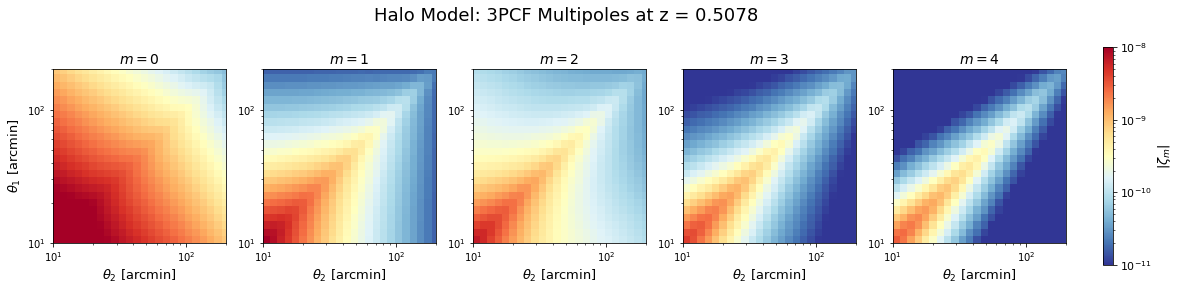

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

path = "/home/sadi/LSST/test/wlcf-main/tests/Bell_outputs"
prefix = "halo_model_z05078_"

theta = np.loadtxt(f"{path}/{prefix}theta_array.txt") * 180 / np.pi * 60
Theta2, Theta1 = np.meshgrid(theta, theta)

fig = plt.figure(figsize=(19, 4))

gs = fig.add_gridspec(
    nrows=1,
    ncols=6,
    width_ratios=[1, 1, 1, 1, 1, 0.06],
    wspace=0.25
)

norm = LogNorm(vmin=1e-11, vmax=1e-8)

for m in range(5):
    ax = fig.add_subplot(gs[0, m])

    zeta = np.abs(np.loadtxt(f"{path}/{prefix}zetam{m}.txt"))

    im = ax.pcolormesh(
        Theta2,
        Theta1,
        zeta,
        shading="auto",
        cmap="RdYlBu_r",
        norm=norm
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(10, 200)
    ax.set_ylim(10, 200)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(fr"$m={m}$", fontsize=14)

    if m == 0:
        ax.set_ylabel(r"$\theta_1$ [arcmin]", fontsize=13)

    ax.set_xlabel(r"$\theta_2$ [arcmin]", fontsize=13)

# Colorbar outside the plots
cax = fig.add_subplot(gs[0, -1])
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r"$|\zeta_m|$", fontsize=13)
cbar.ax.tick_params(labelsize=11)

fig.suptitle(
    "Halo Model: 3PCF Multipoles at z = 0.5078",
    fontsize=18,
    y=1.02
)
plt.savefig("halo_model_3pcf.png", dpi=300, bbox_inches="tight")
plt.show()

## We can also plot

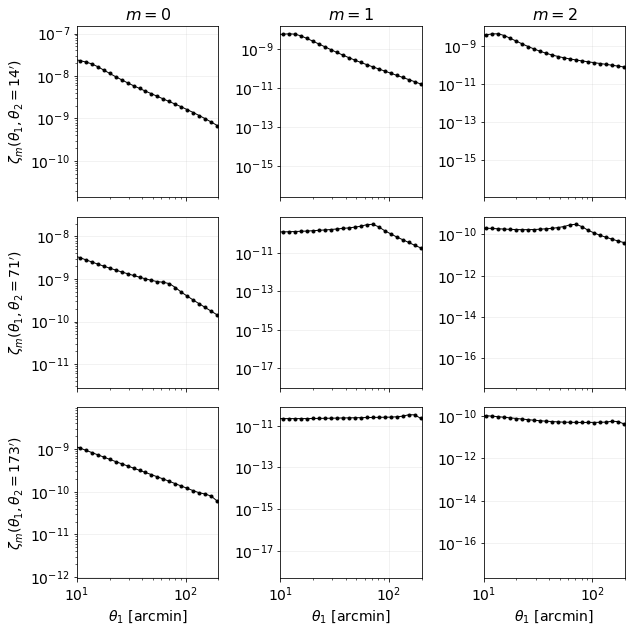

In [7]:
path = "/home/sadi/LSST/test/wlcf-main/tests/Bell_outputs"
prefix = "halo_model_z05078_"

theta = np.loadtxt(f"{path}/{prefix}theta_array.txt") * 180/np.pi * 60

theta2_targets = [13, 72, 169]
m_values = [0, 1, 2]

fig, axes = plt.subplots(
    len(theta2_targets),
    len(m_values),
    figsize=(9, 9),
    sharex=True
)

for i, theta2_fixed in enumerate(theta2_targets):
    idx = np.argmin(np.abs(theta - theta2_fixed))
    theta2_actual = theta[idx]

    for j, m in enumerate(m_values):
        ax = axes[i, j]

        zeta = np.abs(np.loadtxt(f"{path}/{prefix}zetam{m}.txt"))

        # theta2 fixed, theta1 varies
        y = zeta[:, idx]

        ax.plot(theta, y, color="black", marker="o", markersize=3, lw=1)

        ax.set_xscale("log")
        ax.set_yscale("log")

        ax.set_xlim(10, 200)

        if i == 0:
            ax.set_title(fr"$m={m}$")

        if j == 0:
            ax.set_ylabel(
                fr"$\zeta_m(\theta_1,\theta_2={theta2_actual:.0f}')$"
            )

        if i == len(theta2_targets) - 1:
            ax.set_xlabel(r"$\theta_1$ [arcmin]")

        ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("halo_model_slice_3pcf.png", dpi=300, bbox_inches="tight")
plt.show()

## We can also plot the diferent models

In [ ]:
from wlcfpy import wlcf

base_params = dict(
    numberThreads=8,
    verbose=2,
    verbose_log=1,

    # T17 / paper cosmology
    z=0.5078,
    h=0.7,
    sigma8=0.82,
    Omb=0.046,
    Omc=0.233,
    Omnu=0.0,
    ns=0.97,
    w=-1.0,

    # Make sure this P(k) was generated with the same cosmology
    fnamePS="./input/linear_pk_camb_T17_z05078.txt",

    # Redshift bin
    Wg=0,
    fWgchi="./input/Wg_Takahashi_z05078.txt",

    rootDir="Output",
    path_Bells="Bell_outputs",

    zbin=0.5078,
    mMax=5,
    chiQuadSteps=300,
    GLpoints=64,
    Nell=128,
    ellmax=10000,
    ellmin=0.001,
    writevectors=0,
    chatty=2,
    options=""
)

models = {
    1: "SPT",
    2: "Tree",
    3: "EFT",
    4: "Halo_model"
}

for tree_level, model_name in models.items():

    print(f"Running {model_name} model with tree_level={tree_level}")

    params = base_params.copy()
    params["tree_level"] = tree_level
    params["prefix"] = f"{model_name.lower()}_z05078_"

    w = wlcf()
    w.set(params)
    w.Run()

    print(f"Finished {model_name}")

Running SPT model with tree_level=1

Reading input parameters...
Finished SPT
Running Tree model with tree_level=2
startrun_memoryAllocation: Allocated 0 MByte for histograms storage.
StartRun_Common: OmegaM = : 0.279000
time evaluating background: 0.607254 s
iv.chiMaxInt = 1343.988284 Mpc/h
gv.chiBin    = 1349.890696 Mpc/h

Computing Bm(k1,k2) for symmetric array of 100 x 100 k1,k2 values  
Maxm=5, kmin=0.001000 ,kmax=1.000000, Nk=100, GLpoints=64 
z=0.507800, Dp=0.776513, rsigma=1.795962, neff=-1.897866 
Bnk time = 0.43934515 

time= 0.474212 

Bmell: Computing Bm(ell1,ell2) for symmetric 128 x 128 array of ell values
    ellmin = 0.001000, ellmax = 10000.000000  
    Number of moments = 6
    Quadrature chi steps= 300
	Bmell: loop integration time (0) = 0.350222 
	Bmell: loop integration time (1) = 0.324412 
	Bmell: loop integration time (2) = 0.414433 
	Bmell: loop integration time (3) = 0.375224 
	Bmell: loop integration time (4) = 0.319218 
	Bmell: loop integration time (5) = 0.2

 (218) = 0.290113 
	Bmell: loop integration time (219) = 0.294230 
	Bmell: loop integration time (220) = 0.298193 
	Bmell: loop integration time (221) = 0.285423 
	Bmell: loop integration time (222) = 0.321935 
	Bmell: loop integration time (223) = 0.303181 
	Bmell: loop integration time (224) = 0.285000 
	Bmell: loop integration time (225) = 0.312749 
	Bmell: loop integration time (226) = 0.291347 
	Bmell: loop integration time (227) = 0.303639 
	Bmell: loop integration time (228) = 0.296469 
	Bmell: loop integration time (229) = 0.340485 
	Bmell: loop integration time (230) = 0.324120 
	Bmell: loop integration time (231) = 0.295782 
	Bmell: loop integration time (232) = 0.324370 
	Bmell: loop integration time (233) = 0.298346 
	Bmell: loop integration time (234) = 0.307436 
	Bmell: loop integration time (235) = 0.324435 
	Bmell: loop integration time (236) = 0.316999 
	Bmell: loop integration time (237) = 0.282905 
	Bmell: loop integration time (238) = 0.313551 
	Bmell: loop integrat

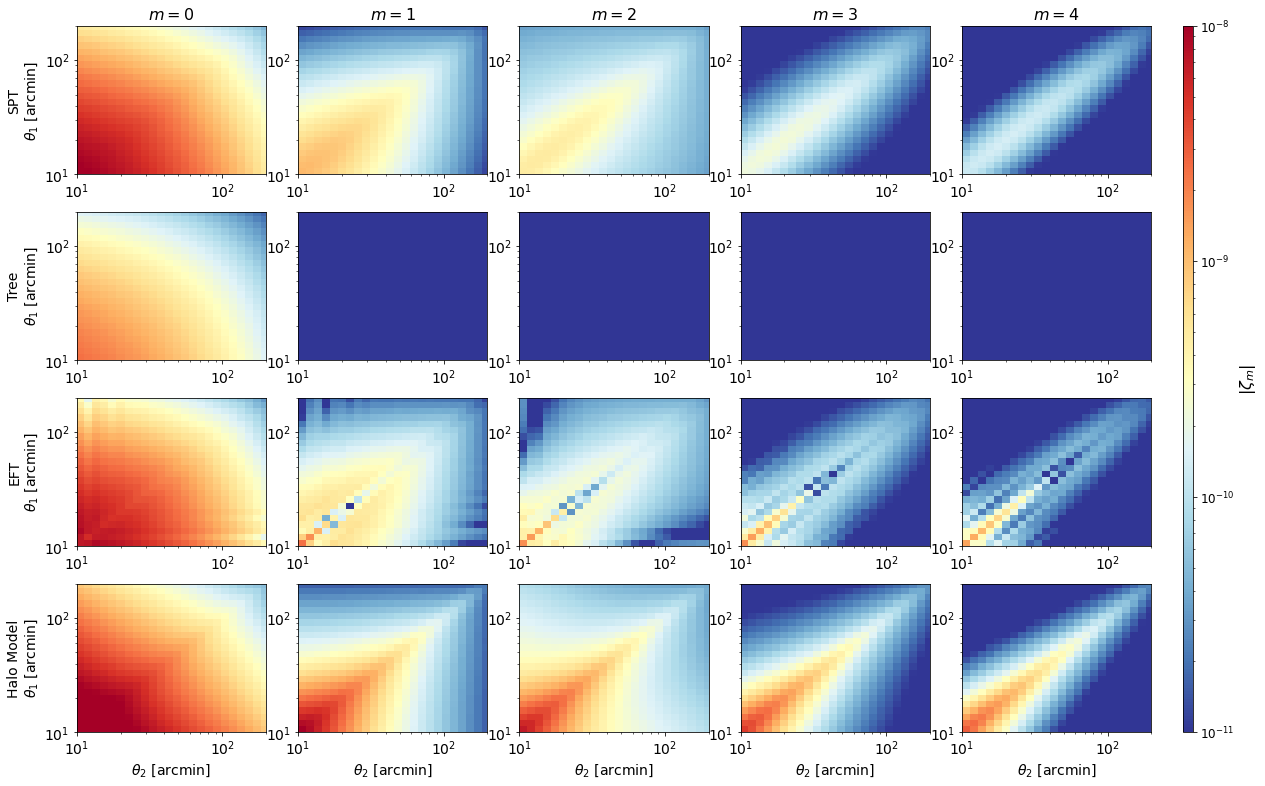

In [ ]:

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14
})

path = "/home/sadi/LSST/test/wlcf-main/tests/Bell_outputs"

models = {
    "SPT": "spt_z05078_",
    "Tree": "tree_z05078_",
    "EFT": "eft_z05078_",
    "Halo Model": "halo_model_z05078_",
}

m_values = range(5)

theta = np.loadtxt(f"{path}/spt_z05_theta_array.txt") * 180 / np.pi * 60
Theta2, Theta1 = np.meshgrid(theta, theta)

nrows = len(models)
ncols = len(m_values)

fig = plt.figure(figsize=(20, 13))

gs = fig.add_gridspec(
    nrows=nrows,
    ncols=ncols + 1,
    width_ratios=[1, 1, 1, 1, 1, 0.05],
    wspace=0.2,
    hspace=0.25
)

norm = LogNorm(vmin=1e-11, vmax=1e-8)

for i, (model_name, prefix) in enumerate(models.items()):
    for j, m in enumerate(m_values):

        ax = fig.add_subplot(gs[i, j])

        zeta = np.abs(np.loadtxt(f"{path}/{prefix}zetam{m}.txt"))

        im = ax.pcolormesh(
            Theta2,
            Theta1,
            zeta,
            shading="auto",
            cmap="RdYlBu_r",
            norm=norm
        )

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlim(10, 200)
        ax.set_ylim(10, 200)

        if i == 0:
            ax.set_title(fr"$m={m}$")

        if j == 0:
            ax.set_ylabel(f"{model_name}\n" + r"$\theta_1$ [arcmin]")

        if i == nrows - 1:
            ax.set_xlabel(r"$\theta_2$ [arcmin]")

cax = fig.add_subplot(gs[:, -1])
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r"$|\zeta_m|$", fontsize=16)
cbar.ax.tick_params(labelsize=12)
plt.savefig("models_3pcf.png", dpi=300, bbox_inches="tight")
plt.show()